In [53]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries loaded")


Libraries loaded


In [54]:
# Enable Inline Plotting in Notebook

%matplotlib inline

print("Inline plotting enabled")


Inline plotting enabled


In [55]:
# Create Sample Data

x = np.linspace(0, 2 * np.pi, 100)
y_sin = np.sin(x)
y_cos = np.cos(x)

print("Sample data created")


Sample data created


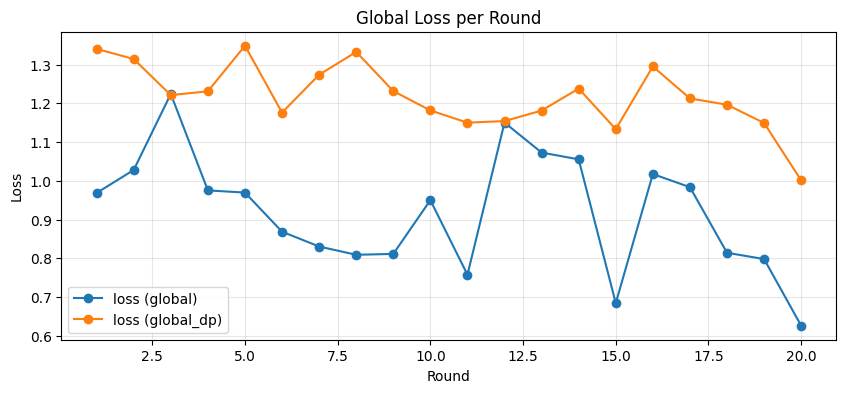

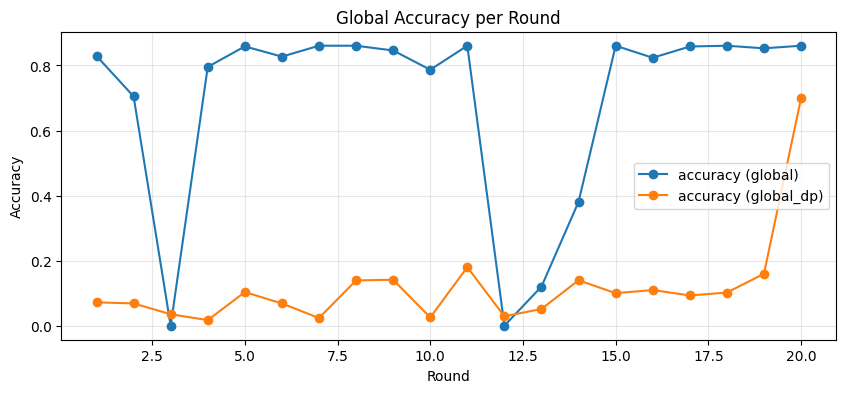

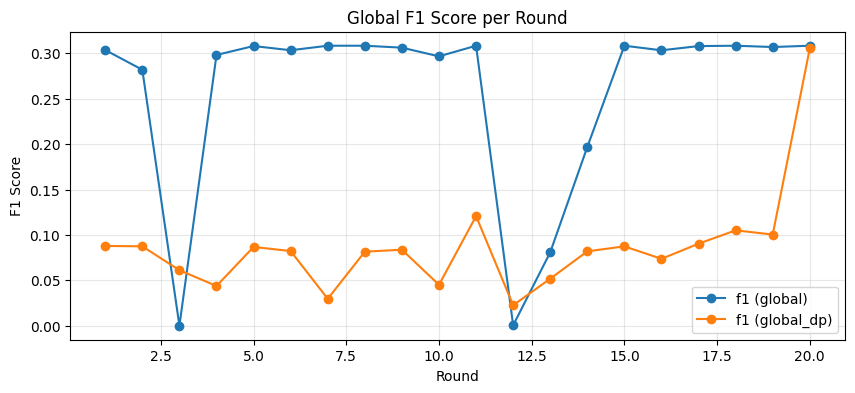

In [61]:
# Load and Plot VFL Metrics (global + client, including DP)

# Change this path if your logs are stored elsewhere.
logs_dir = Path("logs")

# Helper to load metrics (returns None if missing)
def load_csv(path: Path):
    if path.exists():
        return pd.read_csv(path)
    return None

# Load global metrics
metrics_global = load_csv(logs_dir / "metrics_global.csv")
metrics_global_dp = load_csv(logs_dir / "metrics_global_dp.csv")

# Load client metrics
metrics_clients = load_csv(logs_dir / "metrics_clients.csv")
metrics_clients_dp = load_csv(logs_dir / "metrics_clients_dp.csv")



# Plot global metrics (loss + accuracy + F1)
if metrics_global is not None or metrics_global_dp is not None:
    plt.figure(figsize=(10, 4))
    if metrics_global is not None:
        plt.plot(metrics_global["round"], metrics_global["loss"], marker="o", label="loss (global)")
    if metrics_global_dp is not None:
        plt.plot(metrics_global_dp["round"], metrics_global_dp["loss"], marker="o", label="loss (global_dp)")
    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.title("Global Loss per Round")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    if (metrics_global is not None and "accuracy" in metrics_global.columns) or (
        metrics_global_dp is not None and "accuracy" in metrics_global_dp.columns
    ):
        plt.figure(figsize=(10, 4))
        if metrics_global is not None and "accuracy" in metrics_global.columns:
            plt.plot(metrics_global["round"], metrics_global["accuracy"], marker="o", label="accuracy (global)")
        if metrics_global_dp is not None and "accuracy" in metrics_global_dp.columns:
            plt.plot(metrics_global_dp["round"], metrics_global_dp["accuracy"], marker="o", label="accuracy (global_dp)")
        plt.xlabel("Round")
        plt.ylabel("Accuracy")
        plt.title("Global Accuracy per Round")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # Plot F1 score if present
    if (metrics_global is not None and "f1" in metrics_global.columns) or (
        metrics_global_dp is not None and "f1" in metrics_global_dp.columns
    ):
        plt.figure(figsize=(10, 4))
        if metrics_global is not None and "f1" in metrics_global.columns:
            plt.plot(metrics_global["round"], metrics_global["f1"], marker="o", label="f1 (global)")
        if metrics_global_dp is not None and "f1" in metrics_global_dp.columns:
            plt.plot(metrics_global_dp["round"], metrics_global_dp["f1"], marker="o", label="f1 (global_dp)")
        plt.xlabel("Round")
        plt.ylabel("F1 Score")
        plt.title("Global F1 Score per Round")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


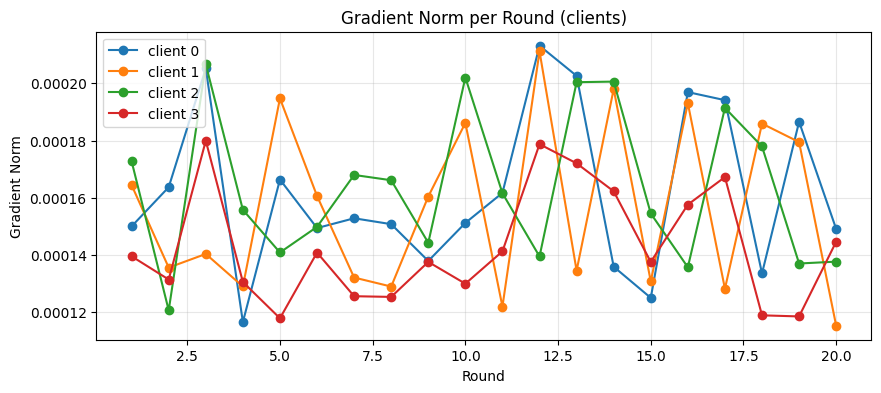

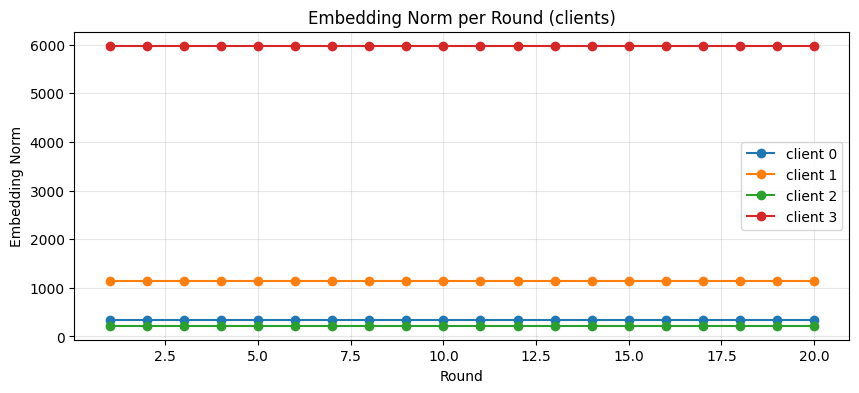

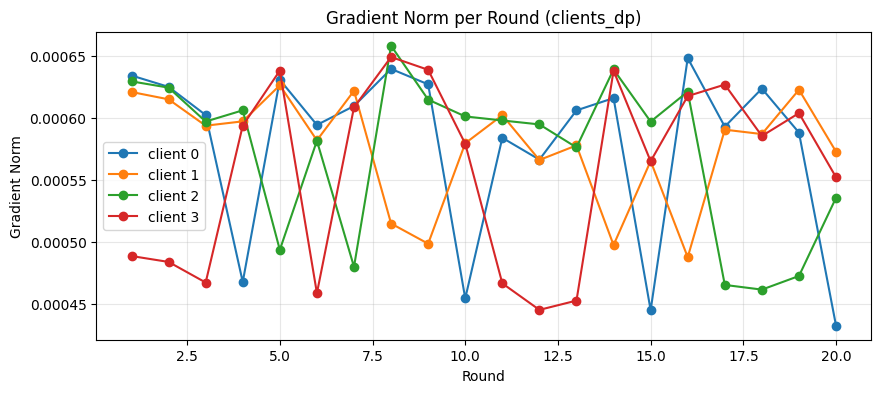

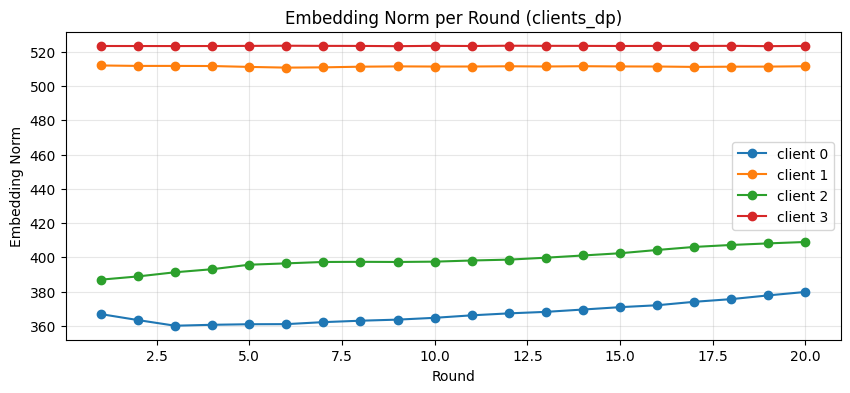

In [60]:

# Plot per-client metrics
for name, df in [("clients", metrics_clients), ("clients_dp", metrics_clients_dp)]:
    if df is None:
        continue

    if "client_id" in df.columns and "grad_norm" in df.columns:
        plt.figure(figsize=(10, 4))
        for client_id, group in df.groupby("client_id"):
            plt.plot(group["round"], group["grad_norm"], marker="o", label=f"client {client_id}")
        plt.xlabel("Round")
        plt.ylabel("Gradient Norm")
        plt.title(f"Gradient Norm per Round ({name})")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    if "client_id" in df.columns and "embedding_norm" in df.columns:
        plt.figure(figsize=(10, 4))
        for client_id, group in df.groupby("client_id"):
            plt.plot(group["round"], group["embedding_norm"], marker="o", label=f"client {client_id}")
        plt.xlabel("Round")
        plt.ylabel("Embedding Norm")
        plt.title(f"Embedding Norm per Round ({name})")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


## Fairness metrics (EOD / SDP) by Sex

We compute **Equal Opportunity Difference (EOD)** and **Statistical Demographic Parity (SDP)** using the saved best models (`best_server_f1*.pt` and `dp_best_server_f1*.pt`).

In [57]:
import numpy as np

# Supposons que raw_df est ton DataFrame et que "Diabetes_binary" est la colonne contenant les labels
label = raw_df["Diabetes_binary"].to_numpy()

# Compter le nombre de 0 et de 1
unique_values, counts = np.unique(label, return_counts=True)

# Afficher les résultats
count_dict = dict(zip(unique_values, counts))
print(f"Nombre de 0 : {count_dict.get(0, 0)}")
print(f"Nombre de 1 : {count_dict.get(1, 0)}")


Nombre de 0 : 218334
Nombre de 1 : 35346


In [59]:
from collections import Counter

# Inspect how predictions map to true labels (confusion counts)
# This helps confirm whether the model is using an unexpected class (e.g. 2) while labels are only {0,1}.

def map_preds(preds, mapping):
    out = preds.copy()
    for src, dst in mapping.items():
        out[out == src] = dst
    return out


def compute_fairness_from_preds(preds, label):
    is_female = sex == 0
    is_male = sex == 1

    def compute_rates(mask):
        y_true = label[mask]
        y_pred = preds[mask]
        tpr = ((y_pred == 1) & (y_true == 1)).sum() / max(1, (y_true == 1).sum())
        ppr = (y_pred == 1).mean()
        return float(tpr), float(ppr)

    tpr_f, ppr_f = compute_rates(is_female)
    tpr_m, ppr_m = compute_rates(is_male)

    return {
        "EOD": tpr_f - tpr_m,
        "SDP": ppr_f - ppr_m,
        "TPR_female": tpr_f,
        "TPR_male": tpr_m,
        "PPR_female": ppr_f,
        "PPR_male": ppr_m,
    }


def inspect_preds(server_ckpt, client_ckpts, label, prefix):
    if server_ckpt is None:
        print(f"{prefix} checkpoint missing")
        return

    model = _load_server_model_from_checkpoint(server_ckpt)
    for m, ckpt in zip(client_models, client_ckpts):
        m.load_state_dict(torch.load(ckpt, weights_only=True))

    embeddings = [m(data_dict[k]).detach() for m, k in zip(client_models, sorted(data_dict.keys()))]
    logits = model(torch.cat(embeddings, dim=1))
    preds = torch.argmax(logits, dim=1).numpy()

    # print(f"\n{prefix} preds unique:", np.unique(preds, return_counts=True))
    # print("label unique:", np.unique(label, return_counts=True))

    # Confusion metrics for the raw predictions (positive class == 1)
    def confusion_counts(y_true, y_pred, positive=1):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        tp = int(((y_true == positive) & (y_pred == positive)).sum())
        tn = int(((y_true != positive) & (y_pred != positive)).sum())
        fp = int(((y_true != positive) & (y_pred == positive)).sum())
        fn = int(((y_true == positive) & (y_pred != positive)).sum())
        return {"TP": tp, "TN": tn, "FP": fp, "FN": fn}

    # Compute fairness and confusion for the raw predictions
    if prefix == "DP":
        metrics_raw = compute_fairness_from_preds(preds, label)
        print(f"{prefix} raw fairness -> {metrics_raw}")
        print(f"{prefix} raw confusion -> {confusion_counts(label, preds)}")
        print("\n")

    # If class 2 is present, also compute metrics after mapping 2 -> 1
    if 2 in preds:
        mapped = map_preds(preds, {2: 1})
        metrics_mapped = compute_fairness_from_preds(mapped, label)
        print(f"{prefix} mapped fairness -> {metrics_mapped}")
        print(f"{prefix} mapped confusion -> {confusion_counts(label, mapped)}")
        print("\n")

    return preds


non_dp_preds = inspect_preds(server_ckpt, client_ckpts, label, "non-DP")
dp_preds = inspect_preds(dp_server_ckpt, dp_client_ckpts, label, "DP")


non-DP mapped fairness -> {'EOD': 0.08558596044774135, 'SDP': 0.05692224902715552, 'TPR_female': 0.20569224919884851, 'TPR_male': 0.12010628875110717, 'PPR_female': 0.13999746432445379, 'PPR_male': 0.08307521529729826}
non-DP mapped confusion -> {'TP': 5821, 'TN': 194999, 'FP': 23335, 'FN': 29525}


DP raw fairness -> {'EOD': 0.0, 'SDP': 0.0006706849637679839, 'TPR_female': 0.0, 'TPR_male': 0.0, 'PPR_female': 0.0013241861185850931, 'PPR_male': 0.0006535011548171092}
DP raw confusion -> {'TP': 0, 'TN': 218073, 'FP': 261, 'FN': 35346}


